# Augmentation on *"The Tortoise Trainer"*

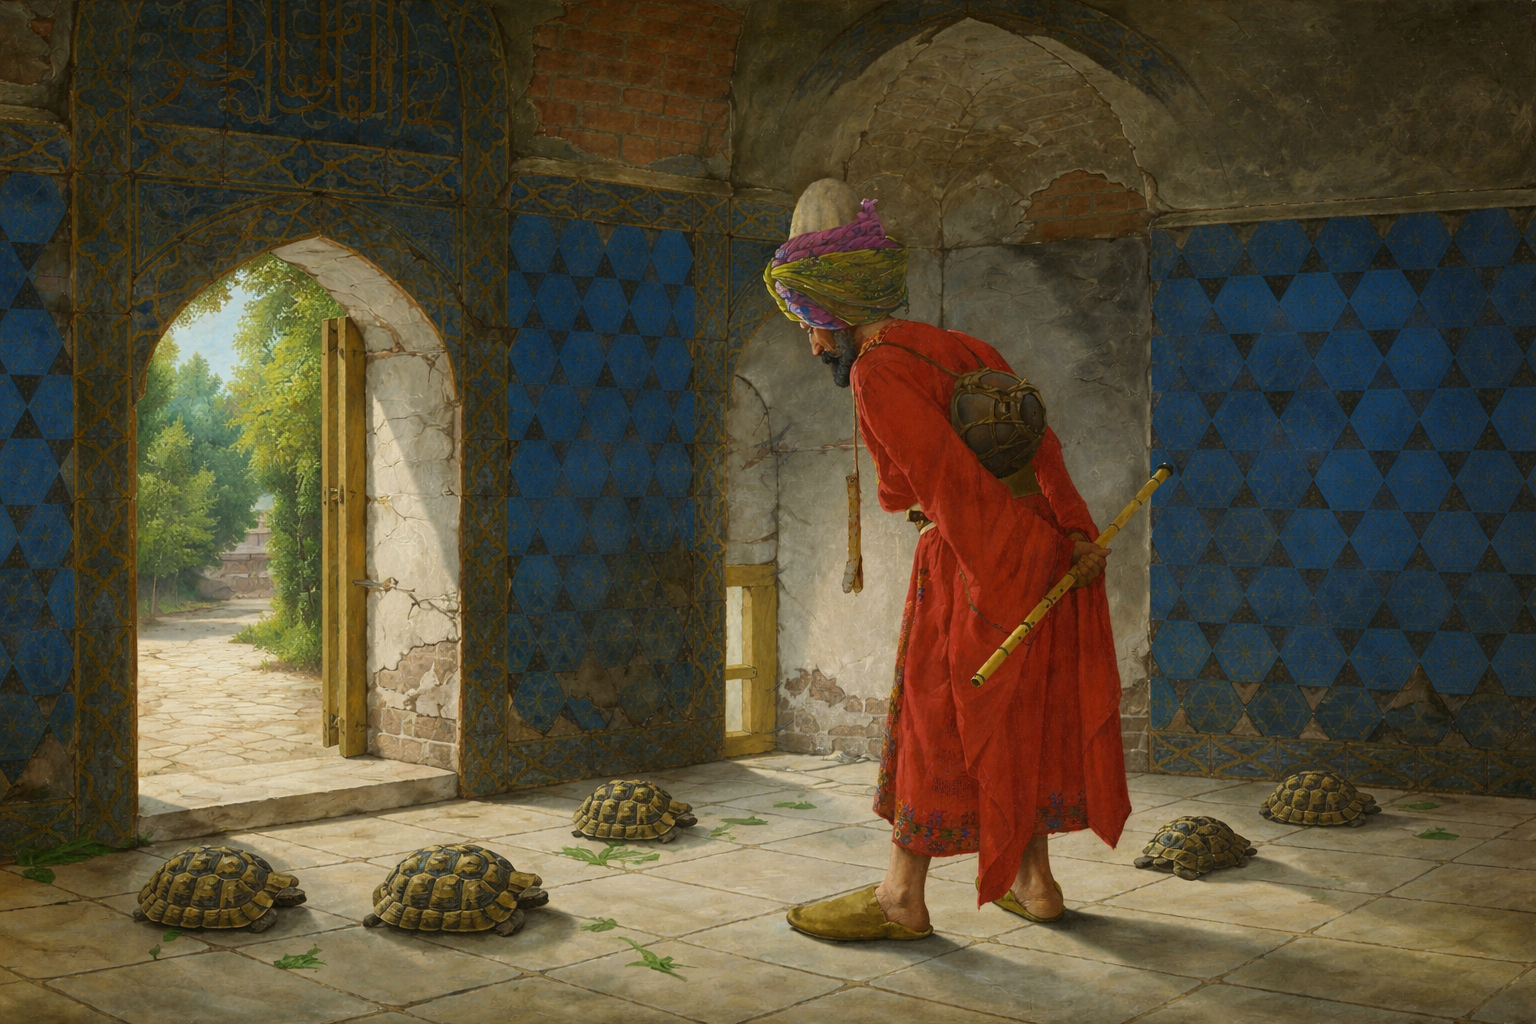

In [1]:
from IPython.display import Image, display

display(Image(filename="../data/raw/the_tortoise trainer_header.png", embed=True))


*Figure digitally altered for header use: Osman Hamdi Bey, The Tortoise Trainer, oil on canvas, 221.5 x 120 cm, Pera Museum. Public domain reproduction. See the Original Figure below*


## Context
This notebook opens MC2 with a deliberately concrete cultural-heritage anchor: Osman Hamdi Bey's *The Tortoise Trainer* (1906), the painting that the Pera Museum acquired in 2004 for a record price and that has since become a visual emblem of Ottoman-era reform debates.

Digital reproductions of paintings like this one travel widely: museum catalogues, education portals, art-history databases. Each digitization pass introduces small but systematic deviations — sensor gain, illumination temperature, light-source positioning and post-processing. Before any downstream analytical task (object detection, classification, structural comparison) it is therefore critical to understand how robust an algorithm is to those non-geometric perturbations. That is the question this notebook addresses with two well-defined operators: linear contrast/brightness adjustment and additive Gaussian noise.


### Data Source

> Osman Hamdi Bey. *Kaplumbaga Terbiyecisi (The Tortoise Trainer)*. 1906, oil on canvas, 221.5 x 120 cm. Pera Museum, Istanbul (Suna and Inan Kirac Foundation collection). Reproduction loaded from [here](https://upload.wikimedia.org/wikipedia/commons/thumb/4/4a/Osman_Hamdi_Bey_-_The_Tortoise_Trainer_-_Google_Art_Project.jpg/960px-Osman_Hamdi_Bey_-_The_Tortoise_Trainer_-_Google_Art_Project.jpg) , originally a public-domain digitization (3:1.85 portrait aspect, ~960 x 1796 px).

The full project repository can be accessed at: <https://github.com/shahatem/gbsv_Turkiye>



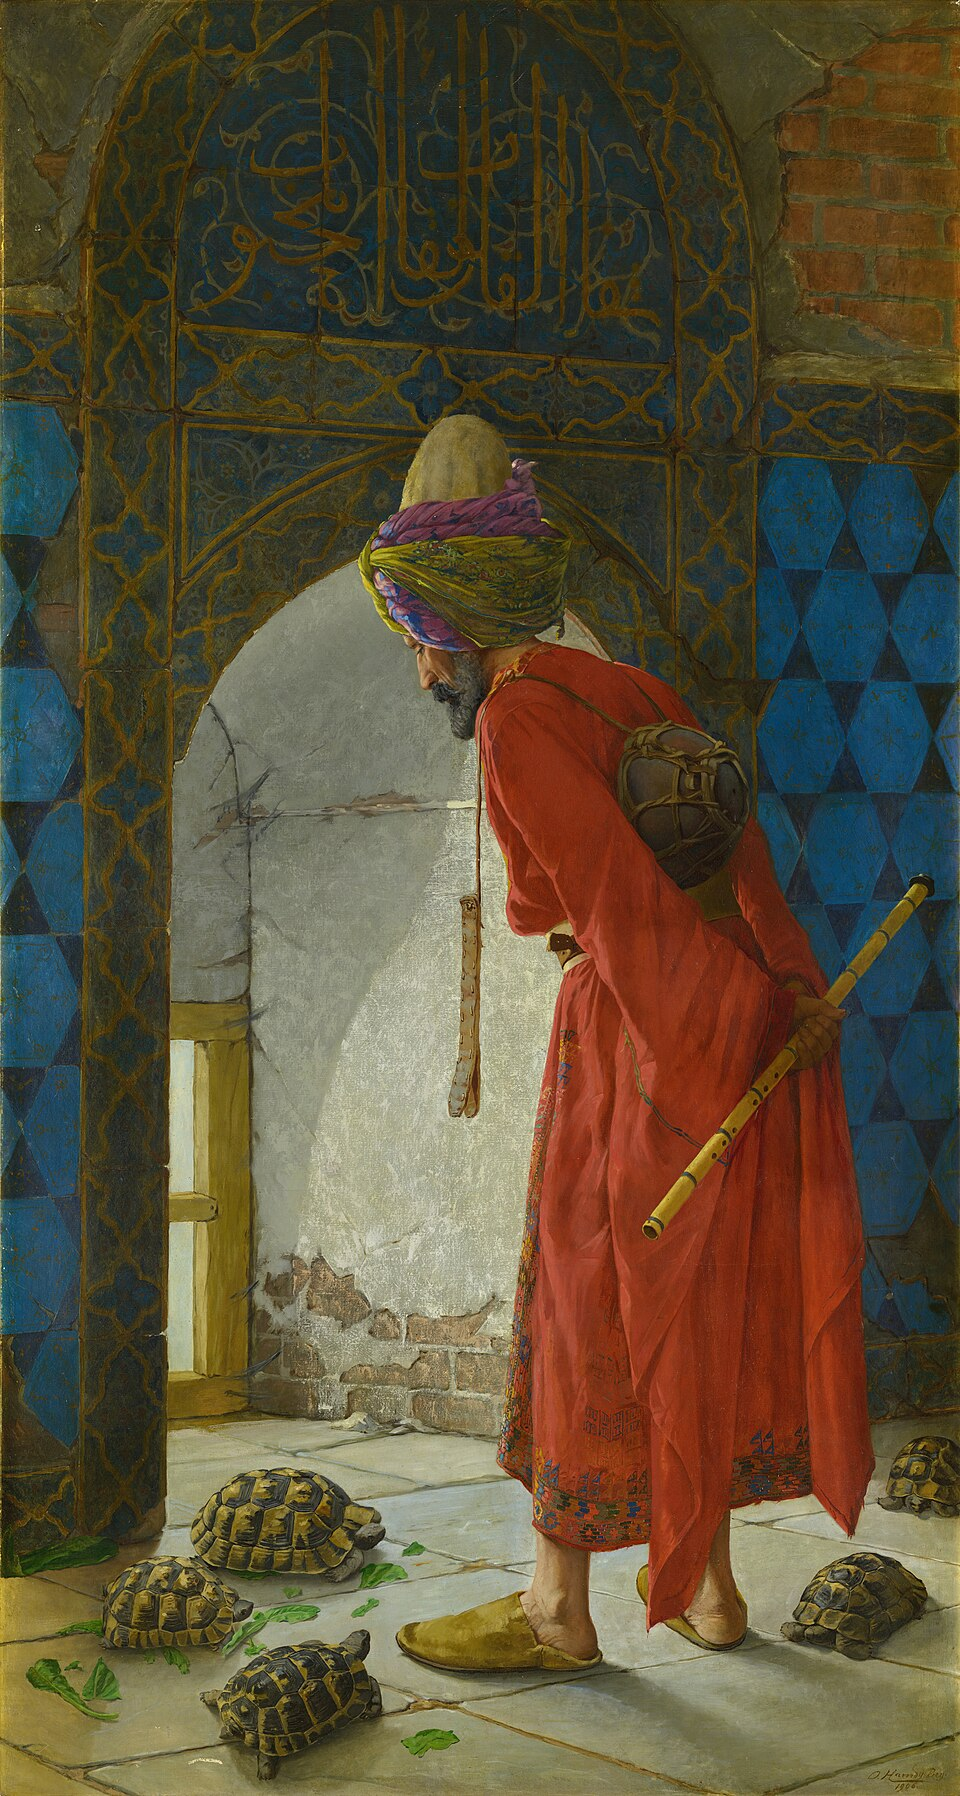

In [2]:
display(Image(filename="../data/raw/Osman_Hamdi_Bey - The_Tortoise_Trainer.jpg", embed=True, width=200))

*Original Figure: Osman Hamdi Bey, The Tortoise Trainer, oil on canvas, 221.5 x 120 cm, Pera Museum. Public domain reproduction*


## Use Case
Pera Museum and partner institutions in Turkiye routinely re-digitize their collections for online catalogues, conservation reports and education programmes. Each new scan is taken with different equipment, ambient light, exposure settings and JPEG pipelines, so the same painting reaches downstream consumers such as search engines, image-similarity tools and condition-monitoring scripts in slightly different photometric form. If a downstream model is sensitive to those harmless variations, the catalogue becomes inconsistent: the same artwork would be ranked differently or a small re-scan would trigger false condition alerts.

The structures that must survive augmentation here are: the dervish robe boundary, the embroidered floor edge, the four tortoise silhouettes near the foot, the calligraphic frieze on the wall and the tonal modelling that gives the figure depth. 

The structures we accept losing under noise are sub-pixel brushwork detail and varnish-level micro-texture. These would not affect the analytic objective.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src" / "image_utils.py").exists():
            return candidate
    raise FileNotFoundError("mc2_images project root not found")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from image_utils import (
    add_gaussian_noise,
    adjust_contrast_brightness,
    crop_region,
    gradient_magnitude,
    load_rgb_image,
    parameter_grid,
    rgb_to_gray,
    save_table,
)
from metrics_utils import mean_structural_similarity, psnr_db, relative_change_percent
from plotting_utils import save_figure, set_plot_style

set_plot_style()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Osman_Hamdi_Bey - The_Tortoise_Trainer.jpg"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

painting = load_rgb_image(DATA_PATH)
painting_gray = rgb_to_gray(painting)
print(f"Painting RGB shape: {painting.shape}, dtype: {painting.dtype}, value range: [{painting.min():.2f}, {painting.max():.2f}]")
print(f"Grayscale shape: {painting_gray.shape}, mean: {painting_gray.mean():.3f}, std: {painting_gray.std():.3f}")


Painting RGB shape: (1796, 960, 3), dtype: float32, value range: [0.00, 1.00]
Grayscale shape: (1796, 960), mean: 0.313, std: 0.163


## Methodological Choices
This notebook does not claim to reconstruct the exact physics of a museum scanner. Instead, it uses two simple, transparent perturbations as a controlled sensitivity test: if visible intensity or noise changes already damage the measured structure of the painting, then the later analysis steps should be treated cautiously.

- **Contrast and brightness shift:** I' = clip(alpha * I + beta). Here, alpha changes contrast and beta adds or subtracts a global brightness offset. This is a deliberately simplified way to test how dependent the image analysis is on tonal calibration.
- **Additive Gaussian noise:** I' = clip(I + N(0, sigma^2)). This does not identify a specific camera or compression process; it simply introduces random pixel-level variation so we can observe when fine details become unstable.

**Assumptions:**
1. The available image is treated as the reference scan for comparison. The metrics therefore measure stability relative to this file, not absolute historical or photographic accuracy.
2. Pixel values are analysed after normalization to [0, 1]. I do not model camera response curves, colour-management profiles or gamma correction, so the results should be read as a practical robustness test, not a calibrated imaging study.
3. The same perturbation is applied to all colour channels. Channel-specific effects, such as a blue or yellow cast, are outside the scope of this notebook.

**Trade-offs:**
- Alpha below 1.0 compresses contrast and makes the already dark foreground flatter; alpha above 1.0 increases separation but can clip bright wall and fabric highlights.
- Negative beta darkens the whole image and can bury tortoise silhouettes in the foreground; positive beta brightens the whole image and can wash out wall ornament and robe modelling.
- Increasing sigma mainly attacks small-scale texture first; large silhouettes remain readable longer than brushwork, calligraphy and tortoise-shell detail.

**Parameter range, derived from the image scale.** The grid is intentionally symmetric and visually legible: alpha in {0.80, 1.00, 1.20} tests a 20 % loss of gain, no contrast change and a 20 % gain increase; beta in {-0.10, 0.00, 0.10} tests darkening and brightening shifts of about 25 grey levels on a [0, 255] scale. For noise, sigma in {0.000, 0.035, 0.070} corresponds to about 0, 9 and 18 grey levels. These values are not presented as universal museum-device constants; they are chosen to create perturbations that are visible to the human eye while remaining plausible for a re-digitized painting.

**Practical Success Criterion.** A configuration is declared **acceptable for downstream cataloguing** when:

- SSIM >= 0.85 against the original (perceptual structural agreement) AND
- PSNR >= 28 dB against the original (signal-level fidelity).

Both bars must be cleared simultaneously. Every sweep row is tagged against this rule so the reader can see which perturbation levels still preserve the image well enough for the stated use case.

## Expected Behaviour
With alpha = 1.00, beta = 0.00, sigma = 0.000 the metrics are mathematically perfect (SSIM = 1.0, PSNR = inf). Moving alpha away from 1.0 should reduce PSNR quickly because every pixel is shifted from the reference. SSIM should be more tolerant when the main silhouettes remain intact, but it should fall when alpha < 1.0 flattens dark foreground structure or alpha > 1.0 clips bright regions. Negative beta should hurt shadow detail first; positive beta should wash out highlights and reduce separation on the wall. Noise should hurt **both** metrics because it injects unstructured high-frequency content the original does not contain. The tortoise silhouettes and the calligraphic frieze should remain readable at the lower noise level but become visibly unstable at the higher one.

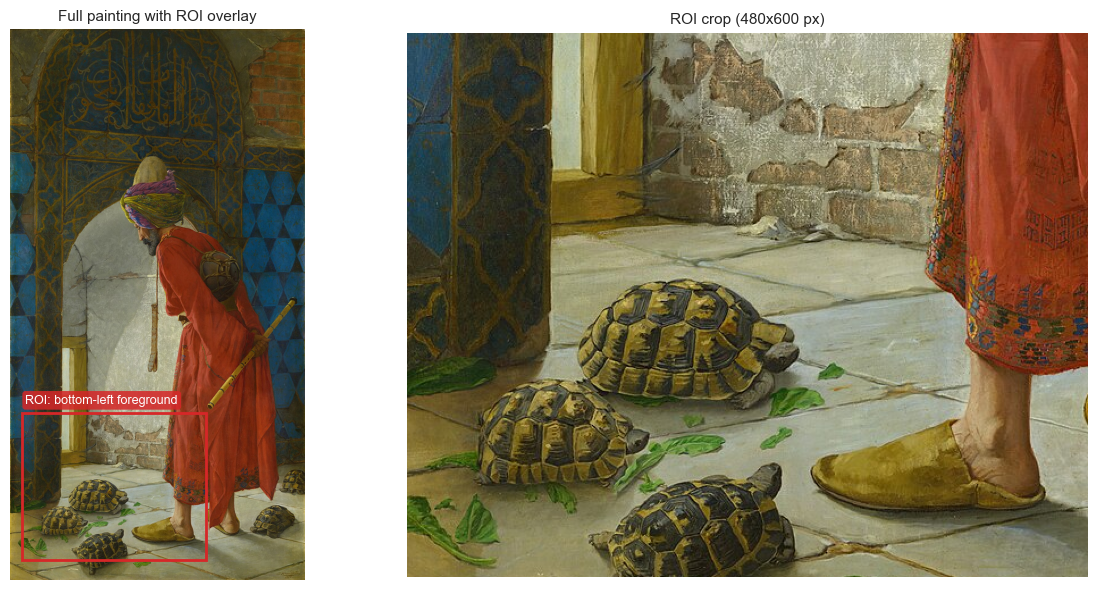

,parameter,value
0,painting_height_px,1796
1,painting_width_px,960
2,roi_top_px,1250
3,roi_left_px,40
4,roi_height_px,480
5,roi_width_px,600
6,alpha_axis,"[0.8, 1.0, 1.2]"
7,beta_axis,"[-0.1, 0.0, 0.1]"
8,sigma_axis,"[0.0, 0.035, 0.07]"
9,ssim_floor,0.85


In [4]:
config = {
    "roi_top": 1250,
    "roi_left": 40,
    "roi_height": 480,
    "roi_width": 600,
    "alpha_axis": [0.80, 1.00, 1.20],
    "beta_axis": [-0.10, 0.00, 0.10],
    "sigma_axis": [0.000, 0.035, 0.070],
    "ssim_floor": 0.85,
    "psnr_floor_db": 28.0,
    "noise_seed": 26,
}
roi = crop_region(painting, config["roi_top"], config["roi_left"], config["roi_height"], config["roi_width"])
roi_gray = rgb_to_gray(roi)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(painting)
rect = plt.Rectangle(
    (config["roi_left"], config["roi_top"]),
    config["roi_width"],
    config["roi_height"],
    edgecolor="tab:red",
    facecolor="none",
    linewidth=2,
)
axes[0].add_patch(rect)
axes[0].set_title("Full painting with ROI overlay")
axes[0].axis("off")
axes[0].text(
    config["roi_left"] + 10,
    config["roi_top"] - 30,
    "ROI: bottom-left foreground",
    color="white",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="tab:red", ec="none", alpha=0.85),
)
axes[1].imshow(roi)
axes[1].set_title(f"ROI crop ({config['roi_height']}x{config['roi_width']} px)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

metadata = pd.DataFrame(
    [
        ("painting_height_px", painting.shape[0]),
        ("painting_width_px", painting.shape[1]),
        ("roi_top_px", config["roi_top"]),
        ("roi_left_px", config["roi_left"]),
        ("roi_height_px", config["roi_height"]),
        ("roi_width_px", config["roi_width"]),
        ("alpha_axis", str(config["alpha_axis"])),
        ("beta_axis", str(config["beta_axis"])),
        ("sigma_axis", str(config["sigma_axis"])),
        ("ssim_floor", config["ssim_floor"]),
        ("psnr_floor_db", config["psnr_floor_db"]),
    ],
    columns=["parameter", "value"],
)
metadata


### Data Structure Evidence
Before running any augmentation we check that *the structures the use case depends on actually exist in this image*. Three quick views make that explicit on the ROI:

1. The ROI crop itself (visual reference).
2. Its grayscale intensity histogram, showing whether the tonal range is rich enough for alpha/beta to have a measurable, non-degenerate effect.
3. Its Sobel gradient magnitude map, showing that the tortoise outlines and floor pattern carry strong local contrast — i.e. the kind of structure that augmentation could erase.

If the ROI looked uniform on (2) or empty on (3), this whole notebook would be testing the wrong image.


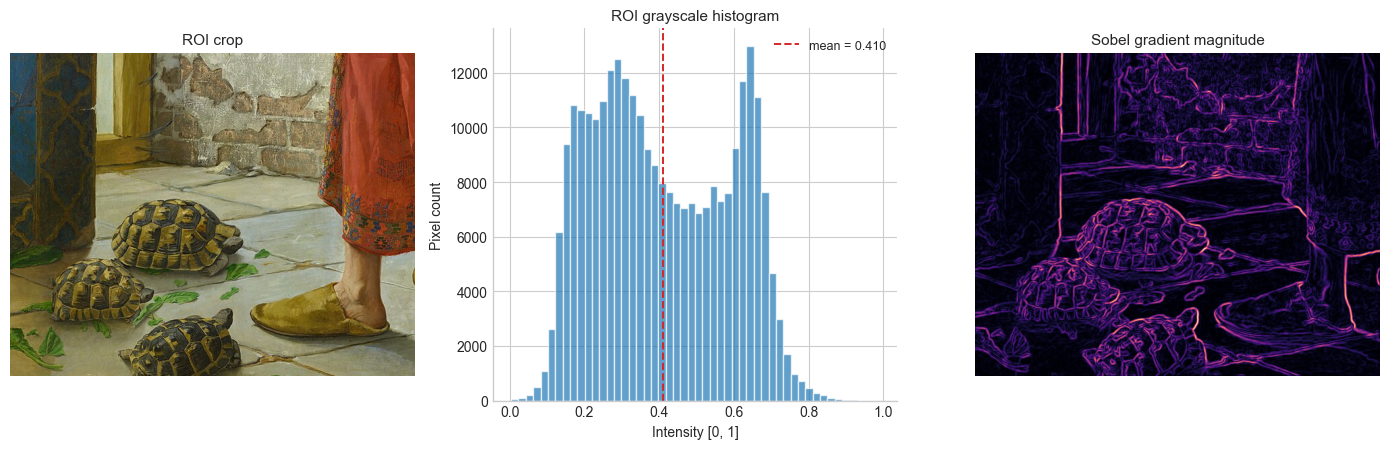

**Evidence summary.** ROI tonal range covers `[0.004, 0.988]` with mean `0.410` and std `0.179`. The gradient magnitude has a 95th percentile of `0.328` and a non-trivial fraction of `13.4%` pixels above 0.2 — i.e. the ROI carries the silhouettes and edges that augmentation could degrade.

In [5]:
roi_gradient = gradient_magnitude(roi_gray, blur_kernel=5)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
axes[0].imshow(roi)
axes[0].set_title("ROI crop")
axes[0].axis("off")
axes[1].hist(roi_gray.ravel(), bins=50, color="tab:blue", alpha=0.7, edgecolor="white")
axes[1].set_title("ROI grayscale histogram")
axes[1].set_xlabel("Intensity [0, 1]")
axes[1].set_ylabel("Pixel count")
axes[1].axvline(roi_gray.mean(), color="tab:red", linestyle="--", linewidth=1.4, label=f"mean = {roi_gray.mean():.3f}")
axes[1].legend(fontsize=9)
axes[2].imshow(roi_gradient, cmap="magma", vmin=0, vmax=1)
axes[2].set_title("Sobel gradient magnitude")
axes[2].axis("off")
plt.tight_layout()
save_figure(fig, OUTPUT_FIGURES / "01_augmentation_data_structure_evidence.png")
plt.show()

display(Markdown(
    f"**Evidence summary.** ROI tonal range covers `[{roi_gray.min():.3f}, {roi_gray.max():.3f}]` with mean `{roi_gray.mean():.3f}` and std `{roi_gray.std():.3f}`. "
    f"The gradient magnitude has a 95th percentile of `{np.percentile(roi_gradient, 95):.3f}` and a non-trivial fraction of `"
    f"{float(np.mean(roi_gradient > 0.2)) * 100:.1f}%` pixels above 0.2 — i.e. the ROI carries the silhouettes and edges that augmentation could degrade."
))


### Implementation: Contrast and Brightness Sweep
The 3x3 grid below applies every (alpha, beta) pair to the full painting, measures SSIM and PSNR against the original and renders each output with its metric pair as caption. The success-criterion bar is overlaid as a single colour ring (green = passes both gates, red = fails one or both).


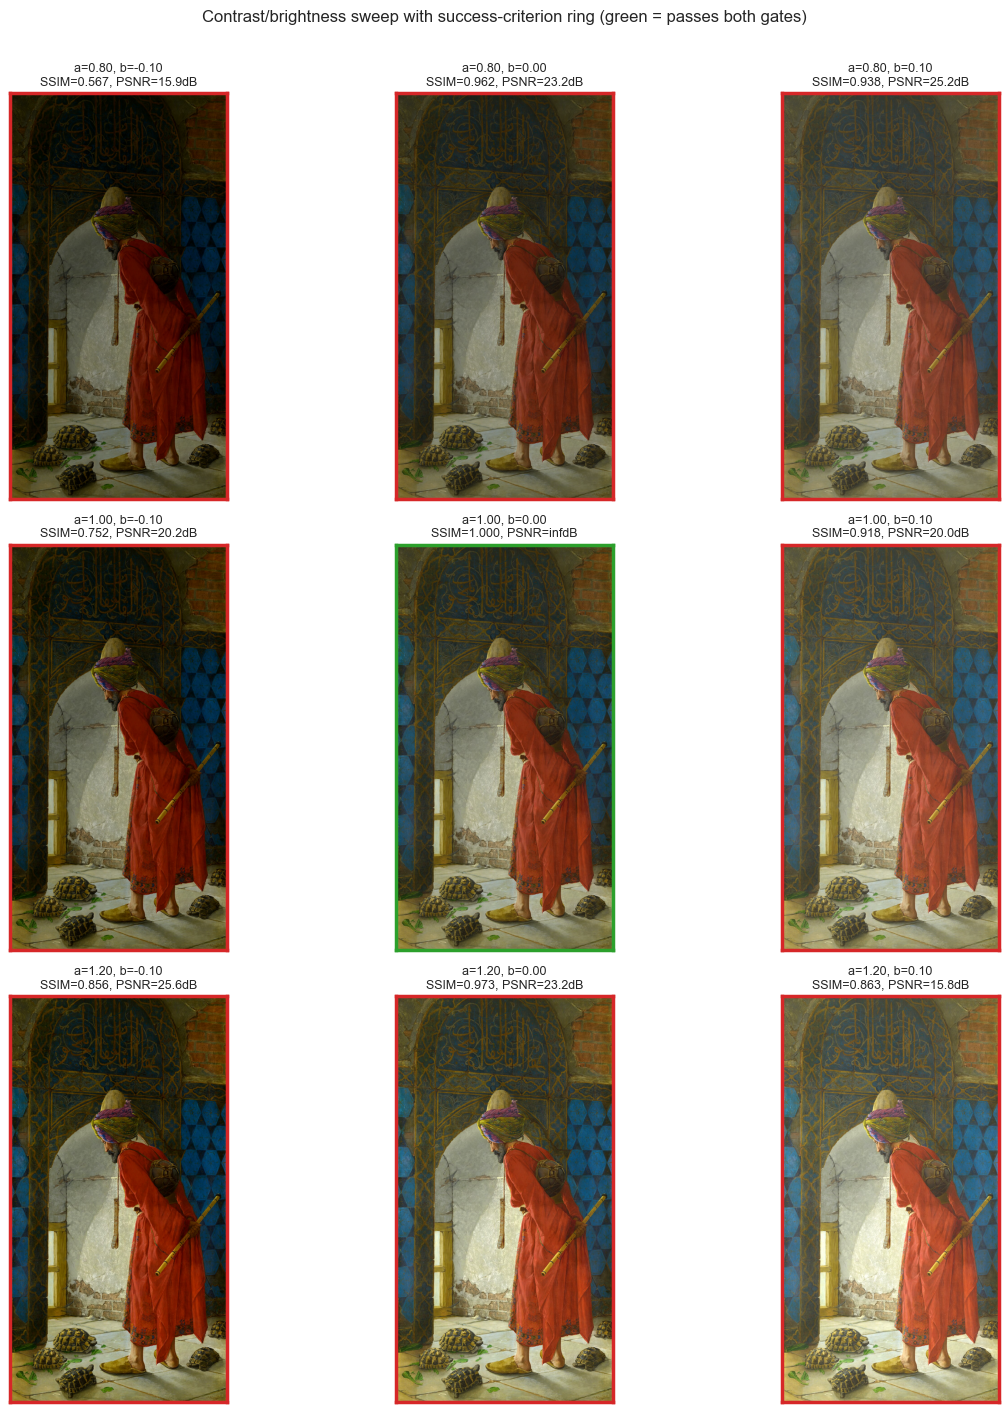

Contrast/brightness configs: 9, passing: 1
SSIM range: [0.567, 1.000]
PSNR range: [15.78 dB, 25.64 dB]


In [6]:
contrast_records = []
fig, axes = plt.subplots(
    len(config["alpha_axis"]),
    len(config["beta_axis"]),
    figsize=(13, 14),
)
for row_idx, alpha in enumerate(config["alpha_axis"]):
    for col_idx, beta in enumerate(config["beta_axis"]):
        augmented = adjust_contrast_brightness(painting, contrast=alpha, brightness=beta)
        ssim = mean_structural_similarity(painting, augmented)
        psnr = psnr_db(painting, augmented)
        passes = (ssim >= config["ssim_floor"]) and (psnr >= config["psnr_floor_db"])
        contrast_records.append({
            "augmentation": "contrast_brightness",
            "alpha": alpha,
            "beta": beta,
            "sigma": 0.0,
            "ssim_to_original": ssim,
            "psnr_db": psnr,
            "passes_criterion": passes,
        })
        ax = axes[row_idx, col_idx]
        ax.imshow(augmented)
        ax.set_xticks([]) 
        ax.set_yticks([])
        ax.set_title(f"a={alpha:.2f}, b={beta:.2f}\nSSIM={ssim:.3f}, PSNR={psnr:.1f}dB", fontsize=9)
        edge_color = "tab:green" if passes else "tab:red"
        for spine_pos in ("left", "right", "top", "bottom"):
            ax.spines[spine_pos].set_visible(True)
            ax.spines[spine_pos].set_edgecolor(edge_color)
            ax.spines[spine_pos].set_linewidth(2.5)
plt.suptitle("Contrast/brightness sweep with success-criterion ring (green = passes both gates)", y=1.005)
plt.tight_layout()
save_figure(fig, OUTPUT_FIGURES / "01_augmentation_contrast_brightness_grid.png")
plt.show()

contrast_df = pd.DataFrame(contrast_records)
print(f"Contrast/brightness configs: {len(contrast_df)}, passing: {int(contrast_df['passes_criterion'].sum())}")
print(f"SSIM range: [{contrast_df['ssim_to_original'].min():.3f}, {contrast_df['ssim_to_original'].max():.3f}]")
print(f"PSNR range: [{contrast_df['psnr_db'].replace([np.inf], np.nan).min():.2f} dB, {contrast_df['psnr_db'].replace([np.inf], np.nan).max():.2f} dB]")


#### Contrast/Brightness Observations
The widened grid makes the metric/visual trade-off much clearer: only the unmodified baseline (alpha = 1.00, beta = 0.00) clears both gates. Every visible contrast or brightness drift fails the PSNR floor, even when SSIM remains structurally high. The most structure-preserving non-baseline row is alpha = 1.20, beta = 0.00 (SSIM = 0.9729), but its PSNR is only 23.17 dB. The nearest SSIM pass with a brightness offset is alpha = 1.20, beta = -0.10 (SSIM = 0.8561), yet it still fails on PSNR at 25.64 dB.

The darkening side is more fragile for this painting: alpha = 0.80, beta = -0.10 drops to SSIM = 0.5668 and PSNR = 15.90 dB because the lower foreground and tortoise zone lose separation. Brightening can also be severe: alpha = 1.20, beta = 0.10 has SSIM = 0.8633 but the worst PSNR in the sweep (15.78 dB), consistent with visible highlight washout. This supports the use case more directly than the previous subtle grid: human-visible photometric drift is already outside the catalogue-safe tolerance.

### Implementation: Gaussian Noise Sweep
The noise axis is studied at fixed (alpha, beta) = (1.00, 0.00) so that its effect can be read independently of the gain/offset trends.


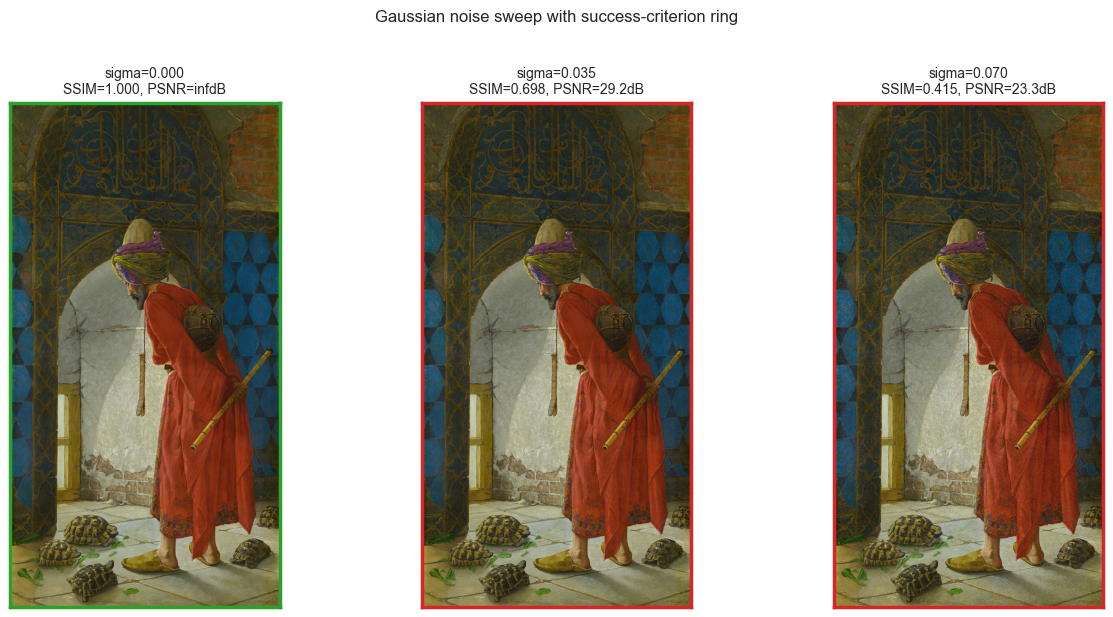

Noise configs: 3, passing: 1
SSIM range: [0.415, 1.000]


In [7]:
noise_records = []
fig, axes = plt.subplots(1, len(config["sigma_axis"]), figsize=(13, 6))
for col_idx, sigma in enumerate(config["sigma_axis"]):
    augmented = add_gaussian_noise(painting, sigma=sigma, seed=config["noise_seed"])
    ssim = mean_structural_similarity(painting, augmented)
    psnr = psnr_db(painting, augmented)
    passes = (ssim >= config["ssim_floor"]) and (psnr >= config["psnr_floor_db"])
    noise_records.append({
        "augmentation": "gaussian_noise",
        "alpha": 1.0,
        "beta": 0.0,
        "sigma": sigma,
        "ssim_to_original": ssim,
        "psnr_db": psnr,
        "passes_criterion": passes,
    })
    ax = axes[col_idx]
    ax.imshow(augmented)
    ax.set_xticks([])   
    ax.set_yticks([])
    ax.set_title(f"sigma={sigma:.3f}\nSSIM={ssim:.3f}, PSNR={psnr:.1f}dB", fontsize=10)
    edge_color = "tab:green" if passes else "tab:red"
    for spine_pos in ("left", "right", "top", "bottom"):
        ax.spines[spine_pos].set_visible(True)
        ax.spines[spine_pos].set_edgecolor(edge_color)
        ax.spines[spine_pos].set_linewidth(2.5)
plt.suptitle("Gaussian noise sweep with success-criterion ring", y=1.02)
plt.tight_layout()
save_figure(fig, OUTPUT_FIGURES / "01_augmentation_noise_grid.png")
plt.show()

noise_df = pd.DataFrame(noise_records)
print(f"Noise configs: {len(noise_df)}, passing: {int(noise_df['passes_criterion'].sum())}")
print(f"SSIM range: [{noise_df['ssim_to_original'].min():.3f}, {noise_df['ssim_to_original'].max():.3f}]")


#### Noise Observations
The noise sweep separates structural and signal-level failure. At sigma = 0.035, PSNR remains above the 28 dB floor (29.16 dB), but SSIM has already dropped to 0.6980. The painting is still recognizable to the eye, yet the metric says the added high-frequency texture is no longer structurally faithful to the reference scan. At sigma = 0.070, both gates fail decisively (SSIM = 0.4147, PSNR = 23.27 dB), and the calligraphic frieze, floor pattern and tortoise-shell details become visibly unstable. The key lesson is that PSNR can be too forgiving of moderate noise, while SSIM reacts earlier to texture that downstream structure-based tools would see as false detail.

### Parameter Sensitivity Study
The two axis sweeps above are merged into a single tidy DataFrame so that all 12 configurations (9 contrast/brightness + 3 noise) can be ranked uniformly. The same DataFrame is also written to CSV for downstream reuse.


In [8]:
sweep_df = pd.concat([contrast_df, noise_df], ignore_index=True)
sweep_df["delta_ssim_pct"] = [relative_change_percent(s, 1.0) for s in sweep_df["ssim_to_original"]]
sweep_df["finite_psnr_db"] = sweep_df["psnr_db"].replace([np.inf], np.nan)

save_table(sweep_df.drop(columns=["finite_psnr_db"]), OUTPUT_TABLES / "01_augmentation_sweep.csv")
print(f"Saved sweep table with {len(sweep_df)} rows -> outputs/tables/01_augmentation_sweep.csv")

display(Markdown(f"**Traceability checkpoint.** n_configs = {len(sweep_df)}, "
                 f"min/max SSIM = {sweep_df['ssim_to_original'].min():.3f} / {sweep_df['ssim_to_original'].max():.3f}, "
                 f"min/max finite PSNR = {sweep_df['finite_psnr_db'].min():.2f} dB / {sweep_df['finite_psnr_db'].max():.2f} dB. "
                 f"Configs passing the criterion: {int(sweep_df['passes_criterion'].sum())} of {len(sweep_df)}."))


def highlight_row(row: pd.Series, target_index: int) -> list[str]:
    if row.name == target_index:
        return ["background-color: #fff3bf"] * len(row)
    return [""] * len(row)


display_df = sweep_df.drop(columns=["finite_psnr_db"]).copy()
non_baseline = sweep_df[(sweep_df["alpha"] != 1.0) | (sweep_df["beta"] != 0.0) | (sweep_df["sigma"] != 0.0)]
best_ssim_index = non_baseline["ssim_to_original"].idxmax()
display(Markdown("**Sweep table (full painting). Best non-trivial SSIM row highlighted.**"))
display(
    display_df.style
    .format({"alpha": "{:.2f}", "beta": "{:.2f}", "sigma": "{:.3f}",
             "ssim_to_original": "{:.4f}", "psnr_db": "{:.2f}", "delta_ssim_pct": "{:.2f}"})
    .apply(lambda row: highlight_row(row, best_ssim_index), axis=1)
)


Saved sweep table with 12 rows -> outputs/tables/01_augmentation_sweep.csv


**Traceability checkpoint.** n_configs = 12, min/max SSIM = 0.415 / 1.000, min/max finite PSNR = 15.78 dB / 29.16 dB. Configs passing the criterion: 2 of 12.

**Sweep table (full painting). Best non-trivial SSIM row highlighted.**

,augmentation,alpha,beta,sigma,ssim_to_original,psnr_db,passes_criterion,delta_ssim_pct
0,contrast_brightness,0.80,-0.10,0.000,0.5668,15.90,False,-43.32
1,contrast_brightness,0.80,0.00,0.000,0.9615,23.16,False,-3.85
2,contrast_brightness,0.80,0.10,0.000,0.9379,25.19,False,-6.21
3,contrast_brightness,1.00,-0.10,0.000,0.7519,20.23,False,-24.81
4,contrast_brightness,1.00,0.00,0.000,1.0000,inf,True,0.00
5,contrast_brightness,1.00,0.10,0.000,0.9178,20.00,False,-8.22
6,contrast_brightness,1.20,-0.10,0.000,0.8561,25.64,False,-14.39
7,contrast_brightness,1.20,0.00,0.000,0.9729,23.17,False,-2.71
8,contrast_brightness,1.20,0.10,0.000,0.8633,15.78,False,-13.67
9,gaussian_noise,1.00,0.00,0.000,1.0000,inf,True,0.00


### Robustness Assessment
The left panel reads SSIM as a function of alpha for each beta line; this exposes whether brightness offset is *additive* on top of the gain effect (parallel curves) or *interactive* (curves diverge). The right panel reads SSIM and PSNR jointly across the noise axis using two y-axes so that the trade-off is visible in one glance.


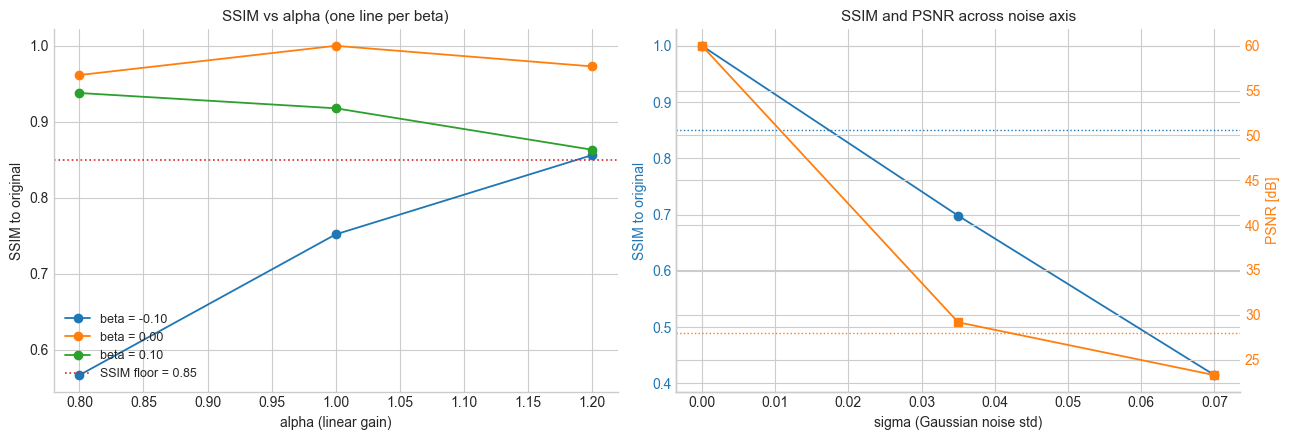

**Best by SSIM (non-trivial):** augmentation = contrast_brightness, alpha = 1.20, beta = 0.00, sigma = 0.000 -> SSIM = 0.9729, PSNR = 23.17 dB.

**Best by PSNR (non-trivial):** augmentation = gaussian_noise, alpha = 1.00, beta = 0.00, sigma = 0.035 -> SSIM = 0.6980, PSNR = 29.16 dB.

**Worst on SSIM:** alpha = 1.00, beta = 0.00, sigma = 0.070 -> SSIM = 0.4147, PSNR = 23.27 dB.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

contrast_clean = sweep_df[sweep_df["augmentation"] == "contrast_brightness"]
for beta_value in sorted(contrast_clean["beta"].unique()):
    subset = contrast_clean[contrast_clean["beta"] == beta_value].sort_values("alpha")
    axes[0].plot(subset["alpha"], subset["ssim_to_original"], marker="o",
                 linewidth=1.3, label=f"beta = {beta_value:.2f}")
axes[0].axhline(config["ssim_floor"], color="tab:red", linestyle=":", linewidth=1.2,
                label=f"SSIM floor = {config['ssim_floor']:.2f}")
axes[0].set_title("SSIM vs alpha (one line per beta)")
axes[0].set_xlabel("alpha (linear gain)")
axes[0].set_ylabel("SSIM to original")
axes[0].legend(loc="lower left", fontsize=9)

noise_clean = sweep_df[sweep_df["augmentation"] == "gaussian_noise"].sort_values("sigma")
ax_left = axes[1]
ax_right = ax_left.twinx()
ax_left.plot(noise_clean["sigma"], noise_clean["ssim_to_original"], marker="o",
             color="tab:blue", linewidth=1.3, label="SSIM")
ax_left.set_xlabel("sigma (Gaussian noise std)")
ax_left.set_ylabel("SSIM to original", color="tab:blue")
ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_left.axhline(config["ssim_floor"], color="tab:blue", linestyle=":", linewidth=1.0)
finite_psnr = noise_clean["psnr_db"].replace([np.inf], 60.0)
ax_right.plot(noise_clean["sigma"], finite_psnr, marker="s",
              color="tab:orange", linewidth=1.3, label="PSNR (capped at 60 dB for plotting)")
ax_right.set_ylabel("PSNR [dB]", color="tab:orange")
ax_right.tick_params(axis="y", labelcolor="tab:orange")
ax_right.axhline(config["psnr_floor_db"], color="tab:orange", linestyle=":", linewidth=1.0)
ax_left.set_title("SSIM and PSNR across noise axis")

plt.tight_layout()
save_figure(fig, OUTPUT_FIGURES / "01_augmentation_parameter_summary.png")
plt.show()

non_baseline = sweep_df[(sweep_df["alpha"] != 1.0) | (sweep_df["beta"] != 0.0) | (sweep_df["sigma"] != 0.0)].copy()
non_baseline["finite_psnr_db"] = non_baseline["psnr_db"].replace([np.inf], np.nan)
best_by_ssim = non_baseline.loc[non_baseline["ssim_to_original"].idxmax()]
best_by_psnr = non_baseline.loc[non_baseline["finite_psnr_db"].idxmax()]
worst = non_baseline.loc[non_baseline["ssim_to_original"].idxmin()]

display(Markdown(
    f"**Best by SSIM (non-trivial):** augmentation = {best_by_ssim['augmentation']}, "
    f"alpha = {best_by_ssim['alpha']:.2f}, beta = {best_by_ssim['beta']:.2f}, sigma = {best_by_ssim['sigma']:.3f} "
    f"-> SSIM = {best_by_ssim['ssim_to_original']:.4f}, PSNR = {best_by_ssim['psnr_db']:.2f} dB.\n\n"
    f"**Best by PSNR (non-trivial):** augmentation = {best_by_psnr['augmentation']}, "
    f"alpha = {best_by_psnr['alpha']:.2f}, beta = {best_by_psnr['beta']:.2f}, sigma = {best_by_psnr['sigma']:.3f} "
    f"-> SSIM = {best_by_psnr['ssim_to_original']:.4f}, PSNR = {best_by_psnr['psnr_db']:.2f} dB.\n\n"
    f"**Worst on SSIM:** alpha = {worst['alpha']:.2f}, beta = {worst['beta']:.2f}, sigma = {worst['sigma']:.3f} "
    f"-> SSIM = {worst['ssim_to_original']:.4f}, PSNR = {worst['psnr_db']:.2f} dB."
))


#### Parameter Study Observations
The two ranking criteria point to different non-trivial configurations. Best-by-SSIM is the contrast-only case alpha = 1.20, beta = 0.00 (SSIM = 0.9729, PSNR = 23.17 dB), while best-by-PSNR is the moderate-noise case sigma = 0.035 (SSIM = 0.6980, PSNR = 29.16 dB). Neither is acceptable because each fails the other gate. Across all 12 rows, only the two mathematically unchanged baseline rows pass; no visible augmentation clears both SSIM and PSNR simultaneously. That is the central robustness result for this use case: the painting can look broadly recognizable while already being too far from the reference for catalogue-stable downstream processing.

## Evaluation And Discussion
The full sweep gives a stricter but more defensible answer to the original problem: once the perturbations are large enough to be visible to the human eye, none of the non-trivial configurations clears both gates. Contrast-only changes preserve structure better than brightness offsets, with alpha = 1.20, beta = 0.00 reaching SSIM = 0.9729 but failing PSNR at 23.17 dB. Brightness shifts are more damaging because they move the whole histogram and clip one side of the tonal range: the darkest case (alpha = 0.80, beta = -0.10) falls to SSIM = 0.5668, while the strongest brightening case (alpha = 1.20, beta = 0.10) keeps SSIM just above the structural floor (0.8633) but has the lowest PSNR at 15.78 dB. Additive noise behaves differently: sigma = 0.035 keeps PSNR acceptable (29.16 dB) while SSIM already fails (0.6980), and sigma = 0.070 fails both metrics.

### Boundary Conditions (when this method fails)
- **Saturated highlights and clipped shadows:** if alpha * I + beta sends bright paint regions above 1.0 or dark foreground regions below 0.0, SSIM/PSNR compare already-truncated data. The dervish's sash and the lower tortoise zone are the most exposed areas in this image.
- **Darker artworks:** this digitization is not actually mid-tone; its grayscale mean is about 0.31. On predominantly dark paintings, negative beta and alpha < 1.0 are especially risky because the same absolute offset consumes a larger share of the available shadow detail.
- **Measured noise range:** sigma = 0.035 already fails the SSIM gate even though PSNR passes; sigma = 0.070 fails both gates. The notebook therefore supports a measured boundary between those two tested levels, not an exact universal noise threshold.
- **Joint perturbations** (high alpha *and* high sigma) are not in this grid; they are expected to compound roughly multiplicatively in PSNR space, but additively in SSIM space, which means the joint regime should be assessed separately rather than extrapolated.

### Methodological Implications
SSIM and PSNR are complementary, not redundant. Reporting only PSNR would hide the moderate-noise case that remains pixel-wise acceptable but structurally degraded; reporting only SSIM would hide contrast-only cases that preserve layout while failing pixel-level fidelity. For Pera Museum and similar Turkish heritage institutions, a defensible digitization audit should therefore report both metrics with explicit thresholds, anchored to the typical tonal range of the collection.

## Conclusion And Reflection
For this use case, linear contrast/brightness modelling combined with additive Gaussian noise is the right minimum operator set: it covers the dominant photometric drifts between Pera Museum scans without committing to assumptions about geometry. Within the visible symmetric parameter range studied here, the painting is not robust enough for catalogue-safe reuse after a non-trivial photometric drift. The only passing rows are the unchanged baselines; visible gain, offset or noise changes fail at least one metric gate.

A practical recommendation for the museum pipeline follows directly: keep re-digitization differences below the visible drift tested here, validate any gain or exposure correction against both SSIM and PSNR before accepting it as the same catalogue image, and treat sigma = 0.035 as already too noisy for structure-based downstream analysis even when PSNR remains above 28 dB. If I extended this notebook I would add a finer local sweep between the unchanged baseline and the first failing visible perturbations, because the current result identifies the visible regime as unsafe but does not locate the exact operational tolerance. I would also add a third axis - gamma, modelling display-side compression - because the success criterion is reported in linear space while end-users view sRGB-compressed renderings, and a gamma sweep would close that gap. Finally, I would generalize the criterion to a per-painting adaptive SSIM floor calibrated on the painting's own tonal range, since a single 0.85 bar is useful here but may be conservative or permissive for other artworks.